# HMM - Macro-indicators (TVTP exploration)

Recall the 7 emission macro-variable in 5-Pure_Macro_HMM:

CUMFNS, Slope, Log_CPI_diff, TB3MS_diff, UMCSENT_diff, UNRATE_diff, NFCI 

The TVTP inputs will be Credit_Spread and Continued_claims  (z-scored excl. COVID, and lagged 2 months to prevent look-ahead bias). 

This is an exploration of TVTP so I wish to keep it simple. Credit Spread and Continued_claims were droppd due to redundancy before so they offer new information for our transition probabilities. 



## Data preparation

Manually reconstruct credit_spread and confirm matches our restricted 1986-start data.
Use baa_yield and gs10_yield.

All good. We z-score excl. COVID and lag by 2 months.

In [1]:
import os
import numpy as np
import pandas as pd
from fredapi import Fred
from dotenv import load_dotenv
from statsmodels.tsa.stattools import adfuller

load_dotenv()
fred = Fred(api_key=os.getenv('FRED_API_KEY'))


def get_series(ticker, name, filepath):
    if os.path.exists(filepath):
        data = pd.read_csv(filepath, index_col=0, parse_dates=True).squeeze()
        data.name = name
    else:
        data = fred.get_series(ticker)
        data.index = pd.to_datetime(data.index)
        data.name = name
        data.to_csv(filepath, header=True)
    return data.ffill().dropna()


def resample_to_monthly(series, method='mean'):
    if method == 'mean':
        return series.resample('ME').mean()
    elif method == 'last':
        return series.resample('ME').last()
    else:
        raise ValueError("method must be 'mean' or 'last'")


# --- pull raw components: Moody's Baa yield and 10Y Treasury constant maturity ---
# same direct-FRED-pull method as every other series in this project, cached the same way
baa_raw = get_series('BAA', 'baa_yield', '../data/baa_yield.csv')
gs10_raw = get_series('GS10', 'gs10_yield', '../data/gs10_yield.csv')

baa_monthly = resample_to_monthly(baa_raw, method='mean')
gs10_monthly = resample_to_monthly(gs10_raw, method='mean')

print(f"BAA raw:  {baa_raw.index.min().date()} to {baa_raw.index.max().date()} ({len(baa_raw)} obs)")
print(f"GS10 raw: {gs10_raw.index.min().date()} to {gs10_raw.index.max().date()} ({len(gs10_raw)} obs)")

credit_spread_manual = (baa_monthly - gs10_monthly).dropna()
credit_spread_manual.name = 'Credit_spread_manual'

print(f"\nCredit_spread_manual (Baa - GS10): {credit_spread_manual.index.min().date()} "
      f"to {credit_spread_manual.index.max().date()} ({len(credit_spread_manual)} obs)")


BAA raw:  1919-01-01 to 2026-07-01 (1291 obs)
GS10 raw: 1953-04-01 to 2026-07-01 (880 obs)

Credit_spread_manual (Baa - GS10): 1953-04-30 to 2026-07-31 (880 obs)


In [2]:
# --- compare against the existing BAA10Y-based Credit_spread, over the overlap window ---
baa10y_raw = get_series('BAA10Y', 'baa10y_spread', '../data/baa10y_spread.csv')
credit_spread_existing = resample_to_monthly(baa10y_raw, method='last')
credit_spread_existing.name = 'Credit_spread_existing'

print(f"Credit_spread_existing (BAA10Y): {credit_spread_existing.index.min().date()} "
      f"to {credit_spread_existing.index.max().date()} ({len(credit_spread_existing)} obs)")

overlap = pd.concat([credit_spread_manual, credit_spread_existing], axis=1).dropna()
corr = overlap['Credit_spread_manual'].corr(overlap['Credit_spread_existing'])
diff = (overlap['Credit_spread_manual'] - overlap['Credit_spread_existing'])

print(f"\noverlap window: {overlap.index.min().date()} to {overlap.index.max().date()} ({len(overlap)} months)")
print(f"correlation: {corr:.4f}")
print(f"mean diff (manual - existing): {diff.mean():.4f}, std diff: {diff.std():.4f}, "
      f"max abs diff: {diff.abs().max():.4f}")
print()
print(overlap.head(6))
print(overlap.tail(6))


Credit_spread_existing (BAA10Y): 1986-01-31 to 2026-06-30 (486 obs)

overlap window: 1986-01-31 to 2026-06-30 (486 months)
correlation: 0.9897
mean diff (manual - existing): -0.0004, std diff: 0.0990, max abs diff: 0.5100

            Credit_spread_manual  Credit_spread_existing
1986-01-31                  2.25                    2.29
1986-02-28                  2.41                    2.49
1986-03-31                  2.72                    2.92
1986-04-30                  2.89                    2.78
1986-05-31                  2.58                    2.36
1986-06-30                  2.54                    2.81
            Credit_spread_manual  Credit_spread_existing
2026-01-31                  1.67                    1.62
2026-02-28                  1.68                    1.80
2026-03-31                  1.79                    1.79
2026-04-30                  1.71                    1.70
2026-05-31                  1.62                    1.57
2026-06-30                  1.53    

In [3]:
# match confirmed (corr=0.99) - proceed with credit_spread_manual as the substitute.
# same pipeline as every other covariate: 2-month lag, ex-COVID z-scoring.
credit_spread_lagged = credit_spread_manual.shift(2)
credit_spread_lagged.name = 'Credit_spread'

print(f"Credit_spread (manual, lagged) first valid: {credit_spread_lagged.first_valid_index().date()}")

adf_report_result = adfuller(credit_spread_lagged.dropna(), autolag='AIC')
print(f"ADF on lagged series: stat={adf_report_result[0]:.4f}  p-value={adf_report_result[1]:.4f}  "
      f"stationary={'YES' if adf_report_result[1] < 0.05 else 'NO'}")

EMISSIONS_WINDOW_START = pd.Timestamp('1976-06-30')

print(f"\nexisting emissions window start: {EMISSIONS_WINDOW_START.date()}")
print(f"credit_spread (manual, lagged) available from: {credit_spread_lagged.first_valid_index().date()}")

if credit_spread_lagged.first_valid_index() <= EMISSIONS_WINDOW_START:
    print("\n-> RESOLVED: manual Credit_spread now covers the full existing 1976-06 emissions "
          "window with no truncation needed - the sample-size conflict is gone, not just reduced.")
else:
    gap_months = (EMISSIONS_WINDOW_START.to_period('M') - credit_spread_lagged.first_valid_index().to_period('M')).n
    print(f"\n-> PARTIALLY RESOLVED: still short of the 1976-06 window start by "
          f"{-gap_months if gap_months < 0 else gap_months} months.")

# z-score using ex-COVID mean/std, applied to the full available window
COVID_WINDOW = ('2020-02-01', '2020-12-31')
cs_full = credit_spread_lagged.dropna()
covid_mask_cs = (cs_full.index >= COVID_WINDOW[0]) & (cs_full.index <= COVID_WINDOW[1])
cs_mean = cs_full.loc[~covid_mask_cs].mean()
cs_std = cs_full.loc[~covid_mask_cs].std()
credit_spread_z = (cs_full - cs_mean) / cs_std

print(f"\nCredit_spread z-scored: {credit_spread_z.index.min().date()} to {credit_spread_z.index.max().date()} "
      f"({len(credit_spread_z)} months), mean(ex-COVID)={cs_mean:.4f}, std(ex-COVID)={cs_std:.4f}")


Credit_spread (manual, lagged) first valid: 1953-06-30
ADF on lagged series: stat=-3.0427  p-value=0.0311  stationary=YES

existing emissions window start: 1976-06-30
credit_spread (manual, lagged) available from: 1953-06-30

-> RESOLVED: manual Credit_spread now covers the full existing 1976-06 emissions window with no truncation needed - the sample-size conflict is gone, not just reduced.

Credit_spread z-scored: 1953-06-30 to 2026-07-31 (878 months), mean(ex-COVID)=1.9001, std(ex-COVID)=0.8008


In [4]:
def apply_transform(series, kind):
    if kind == 'log_diff':
        return np.log(series).diff()
    elif kind == 'diff':
        return series.diff()
    elif kind == 'level':
        return series.copy()
    else:
        raise ValueError("kind must be 'log_diff', 'diff', or 'level'")


# --- rebuild the 7 emission variables, same recipe as 5-Pure_Macro_HMM.ipynb ---
SERIES_CONFIG = {
    'CUMFNS':   {'name': 'cumfns',  'method': 'mean', 'ensae_name': 'CUMFNS',       'kind': 'level'},
    'T10Y2Y':   {'name': 't10y2y',  'method': 'last', 'ensae_name': 'Slope',        'kind': 'level'},
    'CPIAUCSL': {'name': 'cpi',     'method': 'mean', 'ensae_name': 'Log_CPI_diff', 'kind': 'log_diff'},
    'TB3MS':    {'name': 'tb3ms',   'method': 'mean', 'ensae_name': 'TB3MS_diff',   'kind': 'diff'},
    'UMCSENT':  {'name': 'umcsent', 'method': 'mean', 'ensae_name': 'UMCSENT_diff', 'kind': 'diff'},
    'UNRATE':   {'name': 'unrate',  'method': 'mean', 'ensae_name': 'UNRATE_diff',  'kind': 'diff'},
    'NFCI':     {'name': 'nfci',    'method': 'last', 'ensae_name': 'NFCI',         'kind': 'level'},
}
EMISSION_COLS = [cfg['ensae_name'] for cfg in SERIES_CONFIG.values()]

monthly_series = {}
for ticker, cfg in SERIES_CONFIG.items():
    raw = get_series(ticker, cfg['name'], f"../data/{cfg['name']}.csv")
    monthly_series[ticker] = resample_to_monthly(raw, method=cfg['method'])

transformed_series = {}
for ticker, cfg in SERIES_CONFIG.items():
    transformed = apply_transform(monthly_series[ticker], cfg['kind'])
    transformed.name = cfg['ensae_name']
    transformed_series[ticker] = transformed

emissions_full = pd.concat(transformed_series.values(), axis=1, sort=True)[EMISSION_COLS]

first_valid = emissions_full.apply(lambda s: s.first_valid_index())
last_valid = emissions_full.apply(lambda s: s.last_valid_index())
emissions_start, emissions_end = first_valid.max(), last_valid.min()

emissions_df = emissions_full.loc[emissions_start:emissions_end]
assert emissions_df.isna().sum().sum() == 0, "NaNs remain inside the emissions common sample"
print(f"emissions-only common sample: {emissions_df.shape}, "
      f"{emissions_df.index.min().date()} to {emissions_df.index.max().date()}")

COVID_WINDOW = ('2020-02-01', '2020-12-31')
covid_mask = (emissions_df.index >= COVID_WINDOW[0]) & (emissions_df.index <= COVID_WINDOW[1])
emissions_mean = emissions_df.loc[~covid_mask].mean()
emissions_std = emissions_df.loc[~covid_mask].std()
emissions_z = (emissions_df - emissions_mean) / emissions_std


emissions-only common sample: (599, 7), 1976-06-30 to 2026-04-30


In [5]:
# --- Continued_claims (CCSA): same treatment as Credit_spread - pull, lag 2 months ---
ccsa_raw = get_series('CCSA', 'continued_claims', '../data/continued_claims.csv')
continued_claims_monthly = resample_to_monthly(ccsa_raw, method='mean')

continued_claims_lagged = continued_claims_monthly.shift(2)
continued_claims_lagged.name = 'Continued_claims'

print(f"CCSA raw: {ccsa_raw.index.min().date()} to {ccsa_raw.index.max().date()}")
print(f"Continued_claims (lagged) first valid: {continued_claims_lagged.first_valid_index().date()}")

adf_cc = adfuller(continued_claims_lagged.dropna(), autolag='AIC')
print(f"ADF on lagged series: stat={adf_cc[0]:.4f}  p-value={adf_cc[1]:.4f}  "
      f"stationary={'YES' if adf_cc[1] < 0.05 else 'NO'}")


CCSA raw: 1967-01-07 to 2026-05-30
Continued_claims (lagged) first valid: 1967-03-31
ADF on lagged series: stat=-5.9168  p-value=0.0000  stationary=YES


In [6]:
# --- final common window: emissions (7 vars) + Credit_spread (lagged) + Continued_claims (lagged) ---
ORIGINAL_T = 599
ORIGINAL_START, ORIGINAL_END = pd.Timestamp('1976-06-30'), pd.Timestamp('2026-04-30')

candidate_starts = {
    'emissions': emissions_df.index.min(),
    'Credit_spread': credit_spread_lagged.first_valid_index(),
    'Continued_claims': continued_claims_lagged.first_valid_index(),
}
candidate_ends = {
    'emissions': emissions_df.index.max(),
    'Credit_spread': credit_spread_lagged.last_valid_index(),
    'Continued_claims': continued_claims_lagged.last_valid_index(),
}

print(pd.DataFrame({'first_valid': candidate_starts, 'last_valid': candidate_ends}))

final_start = max(candidate_starts.values())
final_end = min(candidate_ends.values())
final_start_var = max(candidate_starts, key=candidate_starts.get)
final_end_var = min(candidate_ends, key=candidate_ends.get)

final_index = emissions_df.loc[final_start:final_end].index
T = len(final_index)

print(f"\nfinal common window: {final_start.date()} to {final_end.date()}  "
      f"(start bound by {final_start_var}, end bound by {final_end_var})")
print(f"T = {T} months")
print(f"original emissions-only window: {ORIGINAL_START.date()} to {ORIGINAL_END.date()}, T={ORIGINAL_T}")

if final_start == ORIGINAL_START and final_end == ORIGINAL_END:
    print("MATCHES the original 599-month window exactly.")
else:
    print(f"FALLS SHORT of the original window by {ORIGINAL_T - T} months "
          f"(start diff: {(final_start - ORIGINAL_START).days} days, "
          f"end diff: {(final_end - ORIGINAL_END).days} days).")


                 first_valid last_valid
emissions         1976-06-30 2026-04-30
Credit_spread     1953-06-30 2026-07-31
Continued_claims  1967-03-31 2026-05-31

final common window: 1976-06-30 to 2026-04-30  (start bound by emissions, end bound by emissions)
T = 599 months
original emissions-only window: 1976-06-30 to 2026-04-30, T=599
MATCHES the original 599-month window exactly.


In [7]:
# --- z-score both covariates using ex-COVID mean/std, same method as emissions,
# computed over this final common window (not each series' own full history) ---
covariates_aligned = pd.concat(
    [credit_spread_lagged.rename('Credit_spread'), continued_claims_lagged.rename('Continued_claims')],
    axis=1
).loc[final_start:final_end]
assert covariates_aligned.isna().sum().sum() == 0, "NaNs remain in covariates after alignment"

covid_mask_final = (covariates_aligned.index >= COVID_WINDOW[0]) & (covariates_aligned.index <= COVID_WINDOW[1])
covariate_mean = covariates_aligned.loc[~covid_mask_final].mean()
covariate_std = covariates_aligned.loc[~covid_mask_final].std()
covariates_z = (covariates_aligned - covariate_mean) / covariate_std

COVARIATE_COLS = ['Credit_spread', 'Continued_claims']
tvtp_inputs = covariates_z[COVARIATE_COLS].to_numpy()

# truncate emissions to the same final window (reusing the existing ex-COVID z-scoring,
# not recomputed, since this matches what any warm-start K=4 model would use)
emissions_z_aligned = emissions_z.loc[final_start:final_end]
observations = emissions_z_aligned[EMISSION_COLS].to_numpy()

print(f"observations (emissions) shape: {observations.shape}")
print(f"tvtp_inputs (covariates) shape: {tvtp_inputs.shape}")
assert observations.shape[0] == tvtp_inputs.shape[0], "T mismatch between emissions and covariates"
print(f"T matches: {observations.shape[0]}")


observations (emissions) shape: (599, 7)
tvtp_inputs (covariates) shape: (599, 2)
T matches: 599


## Determining Logistic regression coefficients

Using the fitted K=4 model from the notebook 5, we run logistic regression of our states on credit_spread, continued_claims and a constant.

We have 598 months and 3 states as we omit COVID. The model fits the optimal intercept and coefficients to produce log-odds of being in each of the 3 regimes (stress, expansion, recovery) for a given month, dependent on spread and claims.

Results make economic sense. We have negative coefficients on each for expansion. A decresed spread and reduced claims implies we are likely in a stable state of growth. 

When running this regression and taking the state with the highest score we get a 68% accuracy. This implies that without knowledge of previous month we obtain a real signal regarding which regime a month is in.

We want COVID to have no response to Credit_spread or Continued_claims in this model as we have a single data point. To prevent any overfitting we claim no sensitivity. The weightings to go INTO COVID shock will be 0s.

In [8]:
import pickle

# load the ACTUAL fitted object from 5-Pure_Macro_HMM.ipynb, rather than
# regenerating via seed (confirmed unreliable cross-process near the Shock
# state's degeneracy - see the earlier discrepancy: ll=-4253.41 vs -4241.72)
with open('../data/processed/k4_model.pkl', 'rb') as f:
    model_k4 = pickle.load(f)

ll = model_k4.score(observations)
print(f"loaded K=4 log-likelihood: {ll:.6f}  (should match -4241.72 exactly)")

viterbi_states = model_k4.predict(observations)
print(f"Viterbi path shape: {viterbi_states.shape}, regime counts: {np.bincount(viterbi_states, minlength=4)}")
print("(expect [153, 1, 331, 114] - Recovery, Shock, Expansion, Stress - matching 5-Pure_Macro_HMM.ipynb)")


loaded K=4 log-likelihood: -4241.719048  (should match -4241.72 exactly)
Viterbi path shape: (599,), regime counts: [153   1 331 114]
(expect [153, 1, 331, 114] - Recovery, Shock, Expansion, Stress - matching 5-Pure_Macro_HMM.ipynb)


In [9]:
from sklearn.linear_model import LogisticRegression

SHOCK_STATE = 1

# drop the single Shock month before fitting - 1 example can't inform a real
# coefficient estimate, and its presence only adds noise to the other 3 states'
# fit. Shock's own TVTP warm-start row is set explicitly below, not fit here.
keep_mask = viterbi_states != SHOCK_STATE
X_fit = tvtp_inputs[keep_mask]
y_fit = viterbi_states[keep_mask]

print(f"dropped {(~keep_mask).sum()} row(s) (Shock), fitting on {len(y_fit)} months, "
      f"{len(np.unique(y_fit))} classes: {sorted(np.unique(y_fit))}")

logreg = LogisticRegression()
logreg.fit(X_fit, y_fit)

print("\nclasses_:", logreg.classes_)
print("\ncoef_ shape:", logreg.coef_.shape, "(n_classes x n_covariates)")
print(pd.DataFrame(logreg.coef_, index=[f'state_{c}' for c in logreg.classes_],
                    columns=COVARIATE_COLS))

print("\nintercept_:")
print(pd.Series(logreg.intercept_, index=[f'state_{c}' for c in logreg.classes_], name='intercept'))

baseline = pd.Series(y_fit).value_counts(normalize=True).max()
train_acc = logreg.score(X_fit, y_fit)
print(f"\ntraining accuracy: {train_acc:.4f}  (naive majority-class baseline: {baseline:.4f})")


dropped 1 row(s) (Shock), fitting on 598 months, 3 classes: [np.int64(0), np.int64(2), np.int64(3)]

classes_: [0 2 3]

coef_ shape: (3, 2) (n_classes x n_covariates)
         Credit_spread  Continued_claims
state_0       0.527818          0.378717
state_2      -0.600968         -0.881756
state_3       0.073150          0.503040

intercept_:
state_0   -0.176177
state_2    0.535133
state_3   -0.358956
Name: intercept, dtype: float64

training accuracy: 0.6806  (naive majority-class baseline: 0.5535)


# Preparing smm inputs

Recall: 

β_ij is essentially the baseline tendency to transition from state i to j

ω_j is the weighting vector (same dimension as Xt) which is the effect of maco variables of wanting to move into regime j.

log_Ps is βs and Ws is ω (we have 1 vector per distination state so is same dim as X_t)

## Example

If currently in Stress state and we want probability of moving to COVID shock with credit_spread and continued_claims X_t:

score = β_{Stress,Shock} + ω_Shock^T · X_t
      = log_Ps[Stress, Shock] + Ws[Shock,:] · X_t
      = -3.557 + [0, 0] · X_t
      = -3.557   (always, regardless of X_t, since Ws[Shock] is all zeros)


## Results

We ensure our shock column matches the original transformation matrix as we preiviouslt excluded but need to consider the single COVID month.

With the weightings and base transition probability matrices prepared we can fit the model.

In [10]:
# --- target: the real transition-INTO-Shock probabilities from the original transmat_ ---
transmat = model_k4.transmat_
print("original K=4 transmat_ (full precision):")
print(transmat)

shock_col = transmat[:, SHOCK_STATE]
print(f"\ntransition-INTO-Shock probabilities, transmat_[:, Shock] = {shock_col}")

# two of these are exact 0.0 (Recovery->Shock, Expansion->Shock never observed) -
# log(0) = -inf would break gradient-based fitting downstream, so floor first
# (same convention used in 5-Pure_Macro_HMM's stability check).
FLOOR = 1e-10
shock_col_floored = np.clip(shock_col, FLOOR, 1.0)
print(f"floored target: {shock_col_floored}")


original K=4 transmat_ (full precision):
[[9.67331054e-01 0.00000000e+00 3.26688312e-02 1.14476699e-07]
 [0.00000000e+00 8.33333333e-01 0.00000000e+00 1.66666667e-01]
 [6.34890221e-03 0.00000000e+00 9.76536299e-01 1.71147987e-02]
 [2.59975420e-02 8.71543228e-03 2.47108405e-02 9.40576185e-01]]

transition-INTO-Shock probabilities, transmat_[:, Shock] = [0.         0.83333333 0.         0.00871543]
floored target: [1.00000000e-10 8.33333333e-01 1.00000000e-10 8.71543228e-03]


In [11]:
from scipy.special import logsumexp

labels_k4 = {0: 'Recovery', 1: 'Shock', 2: 'Expansion', 3: 'Stress'}

K, M = 4, 2
Ws = np.zeros((K, M))
log_Ps = np.zeros((K, K))

# Recovery/Expansion/Stress: Ws rows from the 3-class logreg coefficients (destination-
# indexed, matching ssm's convention); log_Ps columns broadcast from the logreg
# intercepts across every source row i - the plain logistic regression has no
# source-state concept, so this is the only value available for those 3 columns.
for cls, coef_row, intercept in zip(logreg.classes_, logreg.coef_, logreg.intercept_):
    Ws[cls, :] = coef_row
    log_Ps[:, cls] = intercept

Ws[SHOCK_STATE, :] = 0.0

# --- Shock column ---
# log_Ps[i,Shock] = log(transmat_[i,Shock]) alone only fixes the raw exp() value -
# after the FULL row is normalized via softmax against the 3 columns just set
# above (an unrelated source, the logreg intercepts), that alone does NOT
# reproduce the target probability. Those 3 columns are already fixed, so solve
# for log_Ps[i,Shock] such that it lands exactly on target once it competes
# against them. Let S_other[i] = sum of exp(log_Ps[i,j]) over the non-Shock
# columns (already assigned). Need:
#   exp(log_Ps[i,Shock]) / (exp(log_Ps[i,Shock]) + S_other[i]) = target_i
#   => log_Ps[i,Shock] = logit(target_i) + log(S_other[i])
non_shock_cols = [c for c in range(K) if c != SHOCK_STATE]
S_other = np.exp(log_Ps[:, non_shock_cols]).sum(axis=1)
target = shock_col_floored
logit_target = np.log(target) - np.log(1 - target)
log_Ps[:, SHOCK_STATE] = logit_target + np.log(S_other)

state_labels = [f'{i}:{labels_k4[i]}' for i in range(K)]

print("Ws (K x M) - destination-state covariate weights:")
print(pd.DataFrame(Ws, index=state_labels, columns=COVARIATE_COLS))

print("\nlog_Ps (K x K) - [source_i, dest_j] baseline log-odds:")
print(pd.DataFrame(log_Ps, index=state_labels, columns=state_labels))

# --- verify ---
implied_log_P = log_Ps - logsumexp(log_Ps, axis=1, keepdims=True)
implied_P = np.exp(implied_log_P)
print("\nimplied transition matrix at X_t=0 (softmax of log_Ps per row):")
print(pd.DataFrame(implied_P, index=state_labels, columns=state_labels).round(6))

shock_match = np.allclose(implied_P[:, SHOCK_STATE], shock_col_floored, atol=1e-6)
row_sums = implied_P.sum(axis=1)
rows_sum_to_1 = np.allclose(row_sums, 1.0)

print(f"\nShock column matches original transmat_ Shock column: {shock_match}")
print(f"row sums: {row_sums}")
print(f"all rows sum to 1: {rows_sum_to_1}")


Ws (K x M) - destination-state covariate weights:
             Credit_spread  Continued_claims
0:Recovery        0.527818          0.378717
1:Shock           0.000000          0.000000
2:Expansion      -0.600968         -0.881756
3:Stress          0.073150          0.503040

log_Ps (K x K) - [source_i, dest_j] baseline log-odds:
             0:Recovery    1:Shock  2:Expansion  3:Stress
0:Recovery    -0.176177 -21.848874     0.535133 -0.358956
1:Shock       -0.176177   2.786414     0.535133 -0.358956
2:Expansion   -0.176177 -21.848874     0.535133 -0.358956
3:Stress      -0.176177  -3.556930     0.535133 -0.358956

implied transition matrix at X_t=0 (softmax of log_Ps per row):
             0:Recovery   1:Shock  2:Expansion  3:Stress
0:Recovery     0.258424  0.000000     0.526321  0.215255
1:Shock        0.043071  0.833333     0.087720  0.035876
2:Expansion    0.258424  0.000000     0.526321  0.215255
3:Stress       0.256172  0.008715     0.521734  0.213379

Shock column matches origina

##  Fitting the TVTP model using ssm

Recall the baseline odds use both the logistic regression results for the columns of states Recovery, Expansion and Stress and we fill in the shock column such that once it is softmax-normalised it reproduces the original time-invariant transition probabilities exactly. Bit of reverse engineering for convenience

Summary:

- 4 states, 7 gaussian emission variables, 2 TVTP inputs
- Use alpha 1.0 and kappa 5.0 from notebook 5 for persistence of regimes

- Input the weighting, log-P matrices
- Use the fitted means and covariances from notebook 5 for the emission variables.

In [12]:
import ssm

model = ssm.HMM(K=4, D=7, M=2,
                 observations='gaussian',
                 transitions='inputdriven',
                 transition_kwargs=dict(alpha=1.0, kappa=5.0, l2_penalty=1.0))

# inject warm-start observations: means_/covariances from model_k4, converted to
# ssm's (mus, sqrt_Sigmas) format - sqrt_Sigmas is the CHOLESKY factor L such that
# Sigma = L @ L.T, not the raw covariance (confirmed from ssm.observations source:
# GaussianObservations.Sigmas property = matmul(_sqrt_Sigmas, swapaxes(...))).
# small jitter before cholesky, same magnitude ssm's own M-step uses internally,
# as a safety margin given the Shock state's covariance is fit from ~1 month of data.
sqrt_Sigmas = np.linalg.cholesky(model_k4.covars_ + 1e-8 * np.eye(7))
model.observations.params = (model_k4.means_.copy(), sqrt_Sigmas)

# inject warm-start transitions
model.transitions.Ws = Ws.copy()
model.transitions.log_Ps = log_Ps.copy()

print("pre-fit check - Ws:\n", model.transitions.Ws)
print("\npre-fit check - log_Ps:\n", model.transitions.log_Ps)
print("\npre-fit check - observations.mus matches model_k4.means_:",
      np.allclose(model.observations.mus, model_k4.means_))

lls = model.fit(observations, inputs=tvtp_inputs, method='em', initialize=False, num_iters=200)


pre-fit check - Ws:
 [[ 0.52781786  0.37871653]
 [ 0.          0.        ]
 [-0.60096809 -0.88175629]
 [ 0.07315022  0.50303976]]

pre-fit check - log_Ps:
 [[ -0.17617713 -21.84887436   0.53513273  -0.3589556 ]
 [ -0.17617713   2.78641448   0.53513273  -0.3589556 ]
 [ -0.17617713 -21.84887436   0.53513273  -0.3589556 ]
 [ -0.17617713  -3.55692979   0.53513273  -0.3589556 ]]

pre-fit check - observations.mus matches model_k4.means_: True


  0%|          | 0/200 [00:00<?, ?it/s]

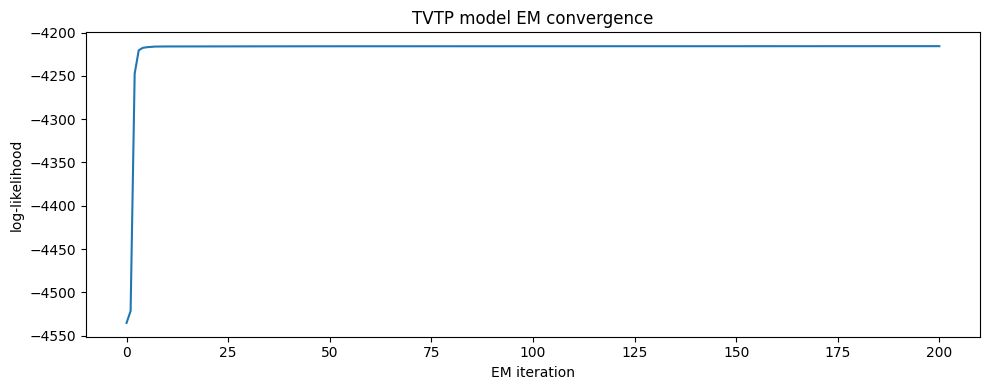

num iterations: 200
ll[0]=-4535.1038  ll[-1]=-4215.7691  total improvement=319.3348
improvement in last 20 iterations: 0.000000 (0.0000% of total)
monotonically increasing: False

NaNs in fitted Ws: False
NaNs in fitted log_Ps: False


In [13]:
import matplotlib.pyplot as plt

lls = np.array(lls)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lls)
ax.set_xlabel('EM iteration')
ax.set_ylabel('log-likelihood')
ax.set_title('TVTP model EM convergence')
plt.tight_layout()
plt.show()

# convergence diagnostics: is it still rising sharply at the end, or plateaued?
total_improvement = lls[-1] - lls[0]
last_10pct_n = max(1, len(lls) // 10)
last_stretch_improvement = lls[-1] - lls[-last_10pct_n - 1]
frac_of_total_in_last_stretch = last_stretch_improvement / total_improvement if total_improvement != 0 else np.nan

print(f"num iterations: {len(lls) - 1}")
print(f"ll[0]={lls[0]:.4f}  ll[-1]={lls[-1]:.4f}  total improvement={total_improvement:.4f}")
print(f"improvement in last {last_10pct_n} iterations: {last_stretch_improvement:.6f} "
      f"({frac_of_total_in_last_stretch:.4%} of total)")
print(f"monotonically increasing: {bool(np.all(np.diff(lls) >= -1e-6))}")

# NaN check on fitted params
Ws_fit = model.transitions.Ws
log_Ps_fit = model.transitions.log_Ps
print(f"\nNaNs in fitted Ws: {np.isnan(Ws_fit).any()}")
print(f"NaNs in fitted log_Ps: {np.isnan(log_Ps_fit).any()}")


In [14]:
# the transitions M-step uses L-BFGS (confirmed from ssm's Transitions.m_step source),
# not a closed-form update, so small non-monotonicity can be numerical noise from an
# imperfectly-converged inner optimization - check the actual size before worrying.
diffs = np.diff(lls)
violations = diffs[diffs < 0]
print(f"iterations with a decrease: {len(violations)} / {len(diffs)}")
if len(violations) > 0:
    print(f"largest decrease: {violations.min():.6f}")
    print(f"decreases at iterations: {np.where(diffs < 0)[0].tolist()}")


iterations with a decrease: 61 / 200
largest decrease: -0.029647
decreases at iterations: [11, 17, 27, 33, 37, 43, 49, 51, 54, 56, 60, 64, 68, 70, 72, 80, 82, 85, 87, 92, 95, 97, 100, 102, 105, 107, 110, 112, 115, 120, 123, 125, 127, 130, 132, 135, 136, 140, 142, 152, 153, 154, 155, 156, 158, 161, 165, 166, 168, 170, 173, 175, 178, 179, 182, 185, 187, 190, 192, 194, 198]


TVTP Viterbi regime counts:          [145   1 338 115]
original K=4 (fixed transitions):    [153   1 331 114]
months where the two paths disagree: 9 / 599


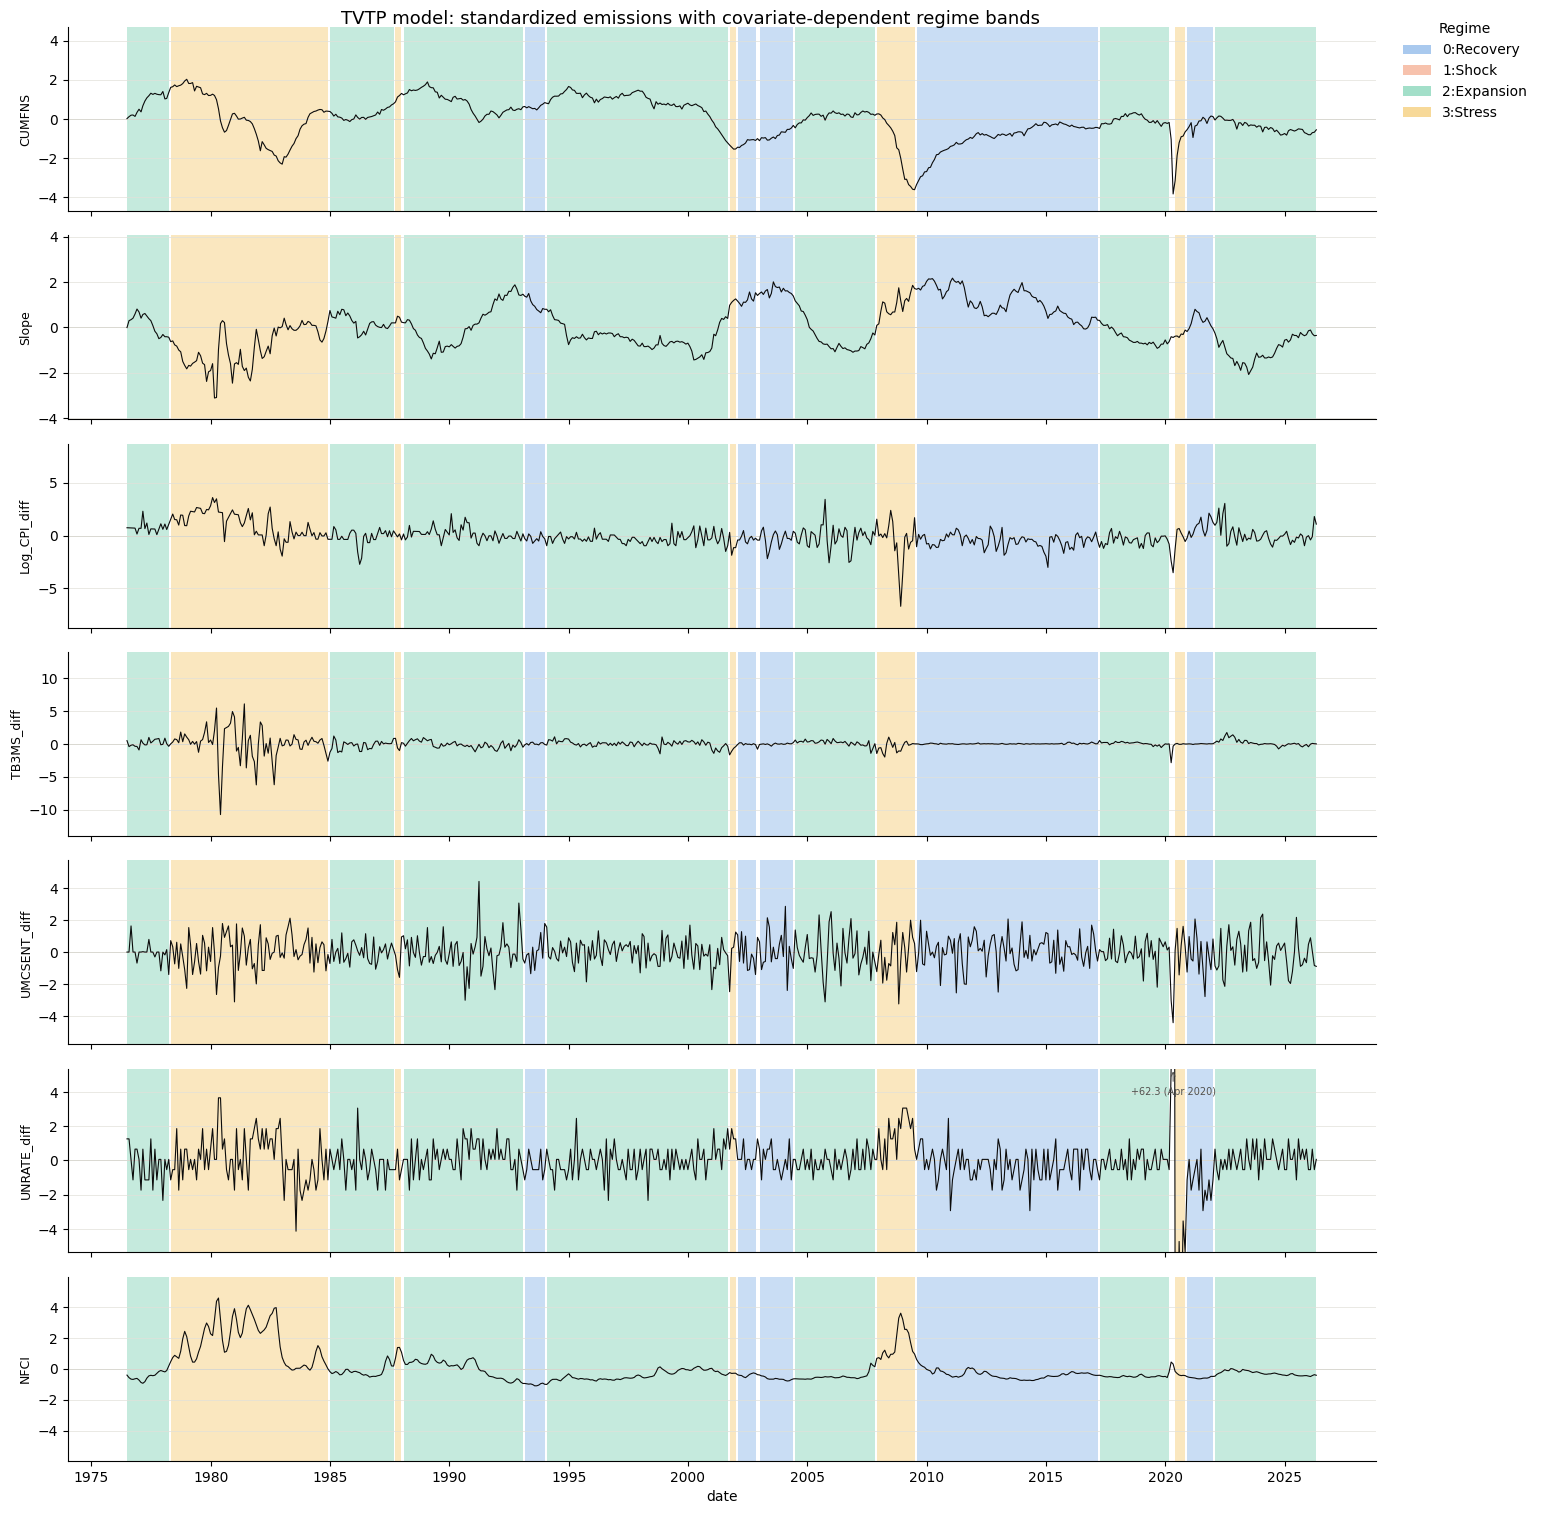

In [15]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# same plotting helpers as 5-Pure_Macro_HMM.ipynb, redefined here (separate kernel)
REGIME_COLORS = {0: '#2a78d6', 1: '#eb6834', 2: '#1baf7a', 3: '#eda100', 4: '#e87ba4'}


def contiguous_regime_blocks(path, dates):
    blocks = []
    start_idx = 0
    for t in range(1, len(path) + 1):
        if t == len(path) or path[t] != path[start_idx]:
            blocks.append((path[start_idx], dates[start_idx], dates[t - 1]))
            start_idx = t
    return blocks


def shade_regimes(ax, blocks):
    for regime, start, end in blocks:
        ax.axvspan(start, end, color=REGIME_COLORS[regime], alpha=0.25, lw=0, zorder=0)


def robust_ylim(series, pad=1.3):
    non_covid_max = series[~covid_mask].abs().max()
    return -non_covid_max * pad, non_covid_max * pad


def annotate_offscale(ax, series, ylo, yhi):
    if series.max() <= yhi and series.min() >= ylo:
        return
    peak_date = series.idxmax() if series.max() > yhi else series.idxmin()
    peak_val = series.loc[peak_date]
    y_edge = yhi if peak_val > 0 else ylo
    ax.annotate(f'{peak_val:+.1f} ({peak_date:%b %Y})', xy=(peak_date, y_edge),
                xytext=(peak_date, y_edge * 0.8), ha='center',
                va='top' if peak_val > 0 else 'bottom', fontsize=7, color='#52514e',
                arrowprops=dict(arrowstyle='->', color='#52514e', lw=0.7))


# TVTP Viterbi path - uses the covariate-dependent transition matrices, not a fixed one
tvtp_states = model.most_likely_states(observations, input=tvtp_inputs)
print(f"TVTP Viterbi regime counts:          {np.bincount(tvtp_states, minlength=4)}")
print(f"original K=4 (fixed transitions):    {np.bincount(viterbi_states, minlength=4)}")
print(f"months where the two paths disagree: {(tvtp_states != viterbi_states).sum()} / {len(viterbi_states)}")

dates_index = emissions_z_aligned.index
tvtp_blocks = contiguous_regime_blocks(tvtp_states, dates_index)

fig, axes = plt.subplots(len(EMISSION_COLS), 1, figsize=(14, 2.2 * len(EMISSION_COLS)), sharex=True)

for ax, col in zip(axes, EMISSION_COLS):
    series = emissions_z_aligned[col]
    shade_regimes(ax, tvtp_blocks)
    ax.plot(dates_index, series, color='#0b0b0b', linewidth=0.8)
    ax.axhline(0, color='#c3c2b7', linewidth=0.6, zorder=0)

    ylo, yhi = robust_ylim(series)
    ax.set_ylim(ylo, yhi)
    annotate_offscale(ax, series, ylo, yhi)

    ax.set_ylabel(col, fontsize=9)
    ax.grid(axis='y', color='#e1e0d9', linewidth=0.5, zorder=0)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('date')

legend_handles = [Patch(facecolor=REGIME_COLORS[k], alpha=0.4, label=f'{k}:{labels_k4[k]}') for k in range(4)]
fig.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.0, 0.98), frameon=False, title='Regime')
fig.suptitle('TVTP model: standardized emissions with covariate-dependent regime bands', fontsize=13)
plt.tight_layout()
plt.show()


In [16]:
Ws_warmstart_df = pd.DataFrame(Ws, index=state_labels, columns=COVARIATE_COLS)
Ws_fitted_df = pd.DataFrame(model.transitions.Ws, index=state_labels, columns=COVARIATE_COLS)

print("Ws - warm-start (pre-fit):")
print(Ws_warmstart_df)
print("\nWs - fitted (post-EM):")
print(Ws_fitted_df)
print("\nWs - change (fitted - warm-start):")
print(Ws_fitted_df - Ws_warmstart_df)


Ws - warm-start (pre-fit):
             Credit_spread  Continued_claims
0:Recovery        0.527818          0.378717
1:Shock           0.000000          0.000000
2:Expansion      -0.600968         -0.881756
3:Stress          0.073150          0.503040

Ws - fitted (post-EM):
             Credit_spread  Continued_claims
0:Recovery        0.557839          0.809668
1:Shock          -0.105509         -1.295949
2:Expansion      -0.434421         -0.200875
3:Stress         -0.017909          0.687156

Ws - change (fitted - warm-start):
             Credit_spread  Continued_claims
0:Recovery        0.030021          0.430952
1:Shock          -0.105509         -1.295949
2:Expansion       0.166547          0.680881
3:Stress         -0.091059          0.184116


In [17]:
disagree_mask = tvtp_states != viterbi_states
disagree_df = pd.DataFrame({
    'fixed_K4': [labels_k4[s] for s in viterbi_states[disagree_mask]],
    'TVTP': [labels_k4[s] for s in tvtp_states[disagree_mask]],
}, index=dates_index[disagree_mask])
disagree_df.index.name = 'date'
print(disagree_df)


             fixed_K4       TVTP
date                            
1978-04-30  Expansion     Stress
2017-03-31   Recovery  Expansion
2017-04-30   Recovery  Expansion
2017-05-31   Recovery  Expansion
2017-06-30   Recovery  Expansion
2017-07-31   Recovery  Expansion
2017-08-31   Recovery  Expansion
2017-09-30   Recovery  Expansion
2017-10-31   Recovery  Expansion


## Results

We observe log-likelihood covergence for the emission meanas/covs, Ws and log_Ps within the first few iterations.

TVTP Regimes 
- All major economic events tracked by time-invariant model also tracked with TVTP. 
- Long expansions & recovery the same
- Comparing the results we have 9 of 599 months disagreeing and these are near regime transitions.

The disgreements:

1978-04: time-invariant = Expansion, TVTP = Stress (identifies Volcker stress first)
2017-03 --> 2017-10: time-invariant = Recovery, TVTP = Expansion

With the 7 2017 months case continued_claims_z is at -0.8 to -1. Low claims is a real signal that allowed the TVTP model to switch regimes before the time-invariant model.

The 1978 case doesn't make as much sense. Continued claims is close to 0 and spread at -1.49 (tight i.e. no stress signal) so this shouldn't be interpreted as any TVTP change. Likely just a marginal boundary shift due to the different model setup.

## Conclusion

Even with 2-month lagged data the TVTP, due to the autocorrelated nature of spreads and claims, identified a regime shift 7 months before the original model.

## Future Steps

Whilst this was just an introduction, developing trading strategies, optimising covariates and further validation testing all seem appropriate.

The ENSAE dynamic allocation strategy obtaining an impressive Sharpe Ratio of 1.08 demonstrates the effectiveness of this approach and further extensions.
